In [1]:
import sys
import os
# Get the absolute path to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# Add it to sys.path
sys.path.append(project_root)
os.chdir(project_root)

In [2]:
import numpy as np
from bimpcc.dataset import get_dataset
from bimpcc.models.tvqregularized_sinbeta_sparse import TVqRegularized
from bimpcc.models.tvq_denoising_sinbeta import TVDenoisingMPCC
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from bimpcc.utils import generate_2D_gradient_matrices

In [3]:
def plot_experiment(true,noisy,u, alpha):
    
    fig,ax = plt.subplots(1,3,figsize=(14,4))
    ax[0].imshow(true,cmap='gray')
    ax[0].set_title('True Image')
    ax[0].axis('off')
    ax[1].imshow(noisy,cmap='gray')
    ax[1].set_title('Noisy Image\nPSNR: {:.4f}'.format(psnr(true,noisy)))
    ax[1].axis('off')
    ax[2].imshow(u,cmap='gray')
    ax[2].set_title(f'Reconstructed Image\nPSNR: {psnr(true,u):.4f}\n alpha = {alpha}')
    # ax[2].set_xlabel('alpha = {}'.format(alpha))
    ax[2].axis('off')

    plt.show()

In [4]:
scale = 4

In [5]:
dataset = get_dataset("cameraman",scale=scale, random_state=1)
true, noisy = dataset.get_training_data()

(np.float64(-0.5), np.float64(3.5), np.float64(3.5), np.float64(-0.5))

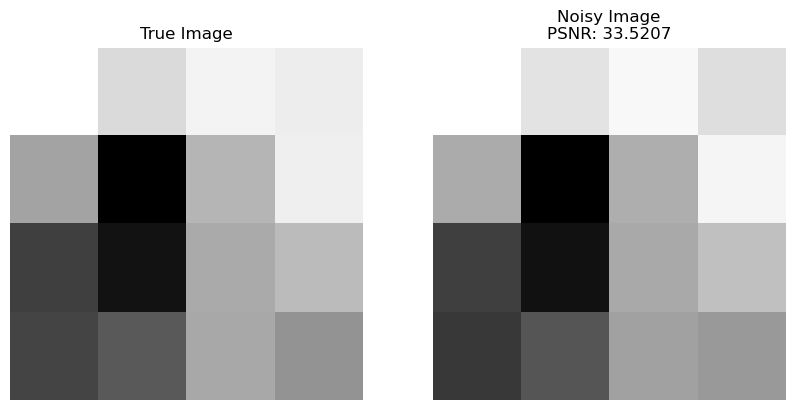

In [6]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(true,cmap='gray')
ax[0].set_title('True Image')
ax[0].axis('off')
ax[1].imshow(noisy,cmap='gray')
ax[1].set_title('Noisy Image\nPSNR: {:.4f}'.format(psnr(true,noisy)))
ax[1].axis('off')

In [7]:
model = TVqRegularized(true, noisy, epsilon=1e-3, q_param=0.72)

In [8]:
res,x_opt,fun_opt = model.solve(max_iter=3000,tol=1e-4,print_level=5)

[100.]
[100.]
[100.]
[100.00051942]
[99.98640664]
[99.98798253]
[99.99002349]
[99.99269551]
[99.99534601]
[99.99954359]
[100.04643562]
[124.35483909]
[167.3963669]
[236.06200653]
[326.9865075]
[423.16129725]
[493.83973804]
[513.98092677]
[514.76296689]
[514.44013229]


In [9]:
u, q, alpha = model.objective_func.parse_vars(x_opt)

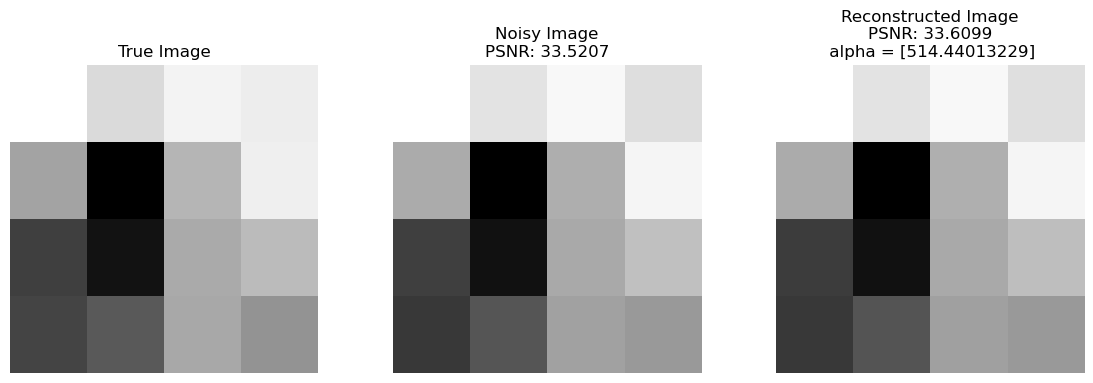

In [10]:
u_scaled = u.reshape((scale,scale))
plot_experiment(true,noisy,u_scaled,alpha)

In [11]:
# x0_q = None
# #vect_q = [0.99, 0.9, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5]
# vect_q = [0.99, 0.9]
# for i in range(len(vect_q)):
#     model = TVqRegularized(true, noisy, epsilon = 1e-3, x0 = x0_q, q_param = vect_q[i])
#     res,x_opt,fun_opt = model.solve(max_iter = 3000,tol = 1e-4,print_level = 5)
#     u, q, alpha = model.objective_func.parse_vars(x_opt)
#     x0_q = np.concatenate((u, q, alpha))

# u_scaled = u.reshape((scale,scale))
# plot_experiment(true,noisy,u_scaled,alpha)
    

In [12]:
Kx, Ky, K = generate_2D_gradient_matrices(scale)

In [13]:
m = q.flatten().size
n = m // 2

Ku = K @ u.flatten()
V = Ku.reshape(2, -1).T
normKu = np.apply_along_axis(np.linalg.norm, axis=1, arr=V)
Q = q.reshape(2,-1).T
normQ = np.apply_along_axis(np.linalg.norm, axis=1, arr=Q)
r0 = normKu
delta0 = normQ

In [14]:
Kxu = Ku[:n]  # Primeras n componentes
Kyu = Ku[n:]  # Últimas n componentes
qx = q[:n]  # Primeras n componentes
qy = q[n:]  # Últimas n componentes
epsilon = 1e-10  

# Condiciones para calcular theta según los casos dados
theta0 = np.zeros(n)  # Inicializamos theta0

# Caso 1: r_i ≠ 0
mask_r_nonzero = r0 > epsilon
theta0[mask_r_nonzero] = np.arccos(Kxu[mask_r_nonzero] / r0[mask_r_nonzero])
theta0[mask_r_nonzero & (Kyu < 0)] *= -1  # Si Ky^i u < 0, negamos theta0

# Caso 2: r_i = 0 y delta_i ≠ 0
mask_r_zero_delta_nonzero = (r0 <= epsilon) & (delta0 > epsilon)
theta0[mask_r_zero_delta_nonzero] = np.arccos(qx[mask_r_zero_delta_nonzero] / delta0[mask_r_zero_delta_nonzero])
theta0[mask_r_zero_delta_nonzero & (qy < 0)] *= -1  # Si qy^i < 0, negamos theta0

# Caso 3: r_i = 0 y delta_i = 0 (theta0 indefinido)
mask_r_zero_delta_zero = (r0 <= epsilon) & (delta0 <= epsilon)
theta0[mask_r_zero_delta_zero] = 0

In [16]:
x0_mpcc = np.concatenate((u.flatten(),q.flatten(),r0,delta0,theta0,alpha))
# print(x0_mpcc)

In [17]:
mpcc_model = TVDenoisingMPCC(true, noisy, x0=x0_mpcc, epsilon=1e-3, q_param = 0.99)

In [19]:
res_mpcc, x_opt_mpcc, fun_opt_mpcc, history = mpcc_model.solve(t_init = 0.001, max_iter=100,tol=1e-4,print_level=5,verbose=True)

Iter   Termination_status            Objective      MPCC_compl               t

0                 0  0.003502208296975128    0.011587044574925306             0.001

1                 0  0.0035031810209487924   0.007736828560213902            0.0005

2                 0  0.0035030662412039253   0.0036020924182209703          0.00025

3                 0  0.003503011008926398    0.0015157418849403176         0.000125

...

6                 0  0.003502977900038392    0.00011054352453833235      1.5625e-05

Intermediate result:  message: b'Algorithm terminated successfully at a locally optimal point, satisfying the 
convergence tolerances (can be specified by options).'
 success: True
  status: 0
     fun: 0.003502977900038392
       x: [ 9.975e-01  9.107e-01 ... -1.760e+00  5.144e+02]
     nit: 5
    info:     status: 0
                   x: [ 9.975e-01  9.107e-01 ... -1.760e+00  5.144e+02]
                   g: [ 2.905e-05  1.081e-05 ...  0.000e+00  0.000e+00]
             obj_val: 0.003502977900038392
              mult_g: [-2.794e-04 -7.607e-04 ... -3.758e-05  1.347e-05]
            mult_x_L: [ 7.823e-10  8.569e-10 ...  0.000e+00  1.517e-12]
            mult_x_U: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
          status_msg: b'Algorithm terminated successfully at a locally optimal point, satisfying the convergence 
tolerances (can be specified by options).'
    nfev: 6
    njev: 7

Intermediate fn: 0.003502977900038392

complementarity: 0.00011054352453833235

* (STOPPED) Iteration 8: Solving the NLP problem for t = 1e-05 with complementarity: 0.00011054352453833235

In [20]:
u_mpcc, q_mpcc, r_mpcc, delta_mpcc, theta_mpcc, alpha_mpcc = mpcc_model.objective_func.parse_vars(x_opt_mpcc)

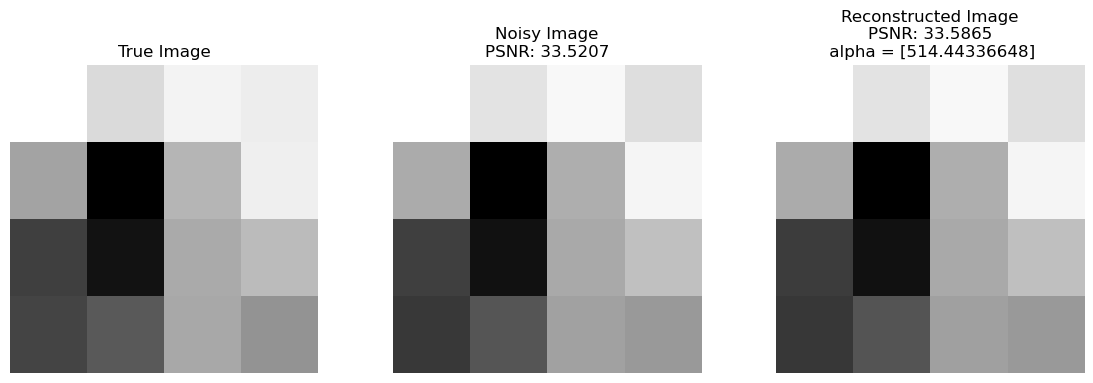

In [21]:
u_mpcc_scaled = u_mpcc.reshape((scale,scale))
plot_experiment(true,noisy,u_mpcc_scaled,alpha_mpcc)

In [22]:
print(delta_mpcc)

[0.99997095 0.99998919 0.99996708 0.9999856  0.99998807 0.99996538
 0.99995588 0.99998449 0.99995428 0.99996564 0.99996694 0.99995445]


In [23]:
u_mpcc

array([0.9975321 , 0.9106678 , 0.973823  , 0.89679302, 0.73819112,
       0.21454832, 0.74915207, 0.96490999, 0.4031351 , 0.26686626,
       0.73209838, 0.79957071, 0.38486624, 0.4732063 , 0.70617774,
       0.68407904])